In [8]:
#!/usr/bin/env python3
"""
==============================================================================
STEP C (v3): PER-HAOR FLOOD ONSET — WITH PERMANENT-WATER MASKING
==============================================================================
FIX over v2: the Z-score onset detector fires "first wet = early" on permanent
water bodies (deep beels, perennial channels) because they were never dry.
This contaminated Tanguar's onset (p10=117, std=25 — a fake early signal from
the permanent Tanguar beel).

This version masks out permanent water using JRC occurrence BEFORE computing
onset statistics. Pixels with JRC occurrence > PERMANENT_WATER_THRESHOLD are
dropped from every haor's onset distribution.

Expected effect after fix:
  - Tanguar's median rises toward the others (~143)
  - Tanguar's std drops from 25 to ~13 (like the rest)
  - All 5 boxplot boxes become tight and overlapping -> confirms simultaneity

Run in Jupyter. Self-contained.
==============================================================================
"""


'\n==============================================================================\nSTEP C (v3): PER-HAOR FLOOD ONSET — WITH PERMANENT-WATER MASKING\n==============================================================================\nFIX over v2: the Z-score onset detector fires "first wet = early" on permanent\nwater bodies (deep beels, perennial channels) because they were never dry.\nThis contaminated Tanguar\'s onset (p10=117, std=25 — a fake early signal from\nthe permanent Tanguar beel).\n\nThis version masks out permanent water using JRC occurrence BEFORE computing\nonset statistics. Pixels with JRC occurrence > PERMANENT_WATER_THRESHOLD are\ndropped from every haor\'s onset distribution.\n\nExpected effect after fix:\n  - Tanguar\'s median rises toward the others (~143)\n  - Tanguar\'s std drops from 25 to ~13 (like the rest)\n  - All 5 boxplot boxes become tight and overlapping -> confirms simultaneity\n\nRun in Jupyter. Self-contained.\n============================================

In [9]:
# %%
# === Imports & paths ===
import os
os.environ["SHAPE_RESTORE_SHX"] = "YES"

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rmask
from rasterio.warp import reproject, Resampling
from shapely.geometry import mapping
import matplotlib.pyplot as plt

BASE = "/work/a06/wasif/haor_flood_analysis"
DIGI_DIR = os.path.join(BASE, "digitization")
DIGI_DIR2 = os.path.join(BASE, "haor_digitization_tanguar")
ANALYSIS_DIR = os.path.join(DIGI_DIR, "analysis")
os.makedirs(ANALYSIS_DIR, exist_ok=True)

HAORS_SHP = os.path.join(DIGI_DIR, "haors_manual.shp")
FIRST_WET_TIF = os.path.join(BASE, "first_wet_date.tif")        # <-- EDIT if filename differs

# JRC permanent-water reference. Two options — the code tries them in order:
#   1. Full-region JRC occurrence raster (preferred if you have it)
#   2. The Tanguar AOI JRC export from your digitization step
JRC_CANDIDATES = [
    os.path.join(BASE, "jrc_occurrence.tif"),
    os.path.join(DIGI_DIR2, "tanguar_jrc_occurrence.tif"),
    os.path.join(BASE, "tanguar_jrc_occurrence.tif"),
]

# Any pixel wetter than this fraction of the JRC record is "permanent" -> dropped
PERMANENT_WATER_THRESHOLD = 75   # JRC occurrence is 0-100 (% of time wet)


In [10]:
# %%
# === Locate the JRC raster ===
JRC_TIF = None
for cand in JRC_CANDIDATES:
    if os.path.exists(cand):
        JRC_TIF = cand
        break

if JRC_TIF is None:
    raise FileNotFoundError(
        "No JRC occurrence raster found. Tried:\n  " +
        "\n  ".join(JRC_CANDIDATES) +
        "\nEdit JRC_CANDIDATES to point to your JRC occurrence GeoTIFF."
    )
print(f"Using JRC permanent-water reference: {JRC_TIF}")
print(f"Permanent-water threshold: occurrence > {PERMANENT_WATER_THRESHOLD}%")


Using JRC permanent-water reference: /work/a06/wasif/haor_flood_analysis/haor_digitization_tanguar/tanguar_jrc_occurrence.tif
Permanent-water threshold: occurrence > 75%


In [11]:
# %%
# === Load + repair haor polygons ===
print("\n=== Loading haor envelopes ===")
haors = gpd.read_file(HAORS_SHP)

n_invalid = (~haors.geometry.is_valid).sum()
if n_invalid > 0:
    print(f"  Repairing {n_invalid} invalid geometry(ies) with buffer(0)")
    haors["geometry"] = haors.geometry.buffer(0)

haors = haors[haors["haor_id"] != "DUMMY"].reset_index(drop=True)
haors_m = haors.to_crs("EPSG:32646")
haors["area_km2"] = haors_m.geometry.area / 1e6

print(f"  {len(haors)} haors:")
for _, h in haors.iterrows():
    print(f"    {h['haor_id']:6s} {h['name_en']:16s} {h['area_km2']:6.1f} km²")



=== Loading haor envelopes ===
  5 haors:
    MTN    Matian Haor        54.2 km²
    SHN    Shanir Haor        82.4 km²
    HLR    Halir Haor         80.4 km²
    TGR    Tanguar Haor       87.4 km²
    GMA    Gumaria Haor       66.3 km²


In [12]:
# %%
# === Helper: extract onset pixels in a haor, with permanent water removed ===
def extract_onset_masked(haor_geom, fwd_src, jrc_src):
    """
    Returns onset-day values inside haor_geom, EXCLUDING:
      - non-positive / nan onset values
      - pixels where JRC occurrence > PERMANENT_WATER_THRESHOLD
    JRC is resampled onto the onset raster's grid for the haor window.
    """
    # 1. Onset pixels in this haor
    geom_fwd = gpd.GeoSeries([haor_geom], crs=haors.crs).to_crs(fwd_src.crs).iloc[0]
    fwd_data, fwd_transform = rmask(fwd_src, [mapping(geom_fwd)], crop=True, filled=False)
    fwd_arr = fwd_data[0]
    fwd_mask = np.ma.getmaskarray(fwd_arr) if np.ma.isMaskedArray(fwd_arr) else np.zeros(fwd_arr.shape, bool)
    fwd_vals = np.ma.filled(fwd_arr, np.nan).astype("float32")

    out_h, out_w = fwd_vals.shape

    # 2. Resample JRC onto the SAME grid as this onset window
    jrc_on_grid = np.full((out_h, out_w), np.nan, dtype="float32")
    reproject(
        source=rasterio.band(jrc_src, 1),
        destination=jrc_on_grid,
        src_transform=jrc_src.transform,
        src_crs=jrc_src.crs,
        dst_transform=fwd_transform,
        dst_crs=fwd_src.crs,
        resampling=Resampling.bilinear,
    )

    # 3. Build the keep-mask: valid onset AND not permanent water
    valid = (~fwd_mask) & np.isfinite(fwd_vals) & (fwd_vals > 0)
    not_permanent = ~(np.isfinite(jrc_on_grid) & (jrc_on_grid > PERMANENT_WATER_THRESHOLD))
    keep = valid & not_permanent

    kept = fwd_vals[keep]
    dropped = int(np.sum(valid & ~not_permanent))   # how many permanent-water px removed
    return kept, dropped


In [13]:
# %%
# === Run extraction for all haors (masked) ===
print("\n=== Extracting onset (permanent water removed) ===")

results = []
with rasterio.open(FIRST_WET_TIF) as fwd_src, rasterio.open(JRC_TIF) as jrc_src:
    for _, h in haors.iterrows():
        kept, dropped = extract_onset_masked(h.geometry, fwd_src, jrc_src)
        if len(kept) == 0:
            print(f"    ! {h['haor_id']} has no valid pixels after masking")
            continue
        results.append({
            "haor_id": h["haor_id"],
            "name_en": h["name_en"],
            "area_km2": round(h["area_km2"], 1),
            "n_pixels": len(kept),
            "n_permanent_dropped": dropped,
            "onset_p10": float(np.percentile(kept, 10)),
            "onset_median": float(np.median(kept)),
            "onset_mean": float(np.mean(kept)),
            "onset_p90": float(np.percentile(kept, 90)),
            "onset_std": float(np.std(kept)),
        })

df = pd.DataFrame(results).sort_values("onset_median").reset_index(drop=True)


=== Extracting onset (permanent water removed) ===


In [14]:
# %%
# === Decision table ===
print("\n" + "=" * 78)
print("PER-HAOR FLOOD ONSET — PERMANENT WATER REMOVED (sorted earliest -> latest)")
print("=" * 78)
print(df[["haor_id", "name_en", "area_km2", "n_pixels", "n_permanent_dropped",
          "onset_p10", "onset_median", "onset_p90", "onset_std"]].to_string(index=False))

spread = df["onset_median"].max() - df["onset_median"].min()
print(f"\nOnset spread (max median - min median): {spread:.1f} days")
print(f"Mean within-haor std: {df['onset_std'].mean():.1f} days")
print(f"Earliest: {df.iloc[0]['name_en']} (day {df.iloc[0]['onset_median']:.1f})")
print(f"Latest:   {df.iloc[-1]['name_en']} (day {df.iloc[-1]['onset_median']:.1f})")

print("\n--- INTERPRETATION ---")
mean_std = df["onset_std"].mean()
if spread < mean_std:
    print(f"  Spread ({spread:.1f}d) < within-haor scatter ({mean_std:.1f}d).")
    print(f"  -> SIMULTANEOUS filling. Differences are smaller than internal noise.")
    print(f"  -> Pivot to fill/drain DYNAMICS (rate of rise vs embankment crest).")
elif spread >= 10:
    print(f"  Spread ({spread:.1f}d) exceeds scatter and is large.")
    print(f"  -> Possible propagation. Check geographic ordering of the sequence.")
else:
    print(f"  Spread ({spread:.1f}d) modest vs scatter ({mean_std:.1f}d). Marginal.")

df.to_csv(os.path.join(ANALYSIS_DIR, "haor_onset_stepC_masked.csv"), index=False)
print(f"\n✓ Saved: {os.path.join(ANALYSIS_DIR, 'haor_onset_stepC_masked.csv')}")



PER-HAOR FLOOD ONSET — PERMANENT WATER REMOVED (sorted earliest -> latest)
haor_id      name_en  area_km2  n_pixels  n_permanent_dropped  onset_p10  onset_median  onset_p90  onset_std
    TGR Tanguar Haor      87.4      6060                 2208 119.503464    138.498016 150.498016  15.381295
    MTN  Matian Haor      54.2      4532                 1136 138.497726    143.503479 152.991455  12.088884
    HLR   Halir Haor      80.4      7577                 1093 138.497726    143.503479 152.991455  11.396462
    GMA Gumaria Haor      66.3      6252                  711 133.997223    143.503479 152.991455  16.059225
    SHN  Shanir Haor      82.4      7221                 1276 140.991455    150.497726 152.991455  13.403778

Onset spread (max median - min median): 12.0 days
Mean within-haor std: 13.7 days
Earliest: Tanguar Haor (day 138.5)
Latest:   Shanir Haor (day 150.5)

--- INTERPRETATION ---
  Spread (12.0d) < within-haor scatter (13.7d).
  -> SIMULTANEOUS filling. Differences are sma


=== Boxplot (masked) ===


/tmp/ipykernel_1452178/3911564768.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data,


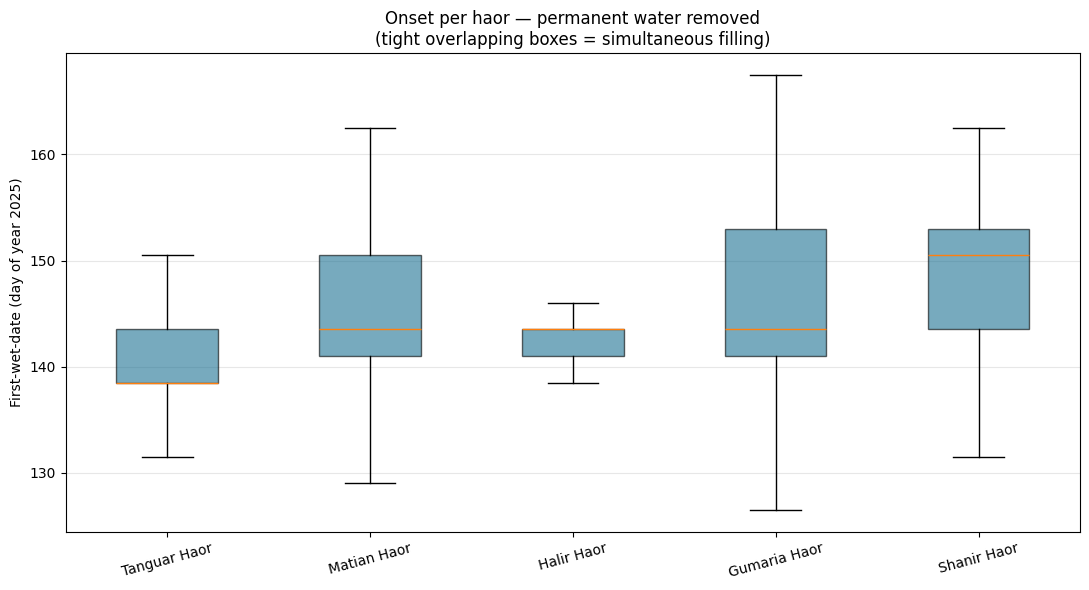

✓ Saved: /work/a06/wasif/haor_flood_analysis/digitization/analysis/haor_onset_boxplot_masked.png


In [15]:
# %%
# === Boxplot: do the boxes separate or overlap (after masking)? ===
print("\n=== Boxplot (masked) ===")
order = df["haor_id"].tolist()
box_data = []
with rasterio.open(FIRST_WET_TIF) as fwd_src, rasterio.open(JRC_TIF) as jrc_src:
    for hid in order:
        h = haors[haors["haor_id"] == hid].iloc[0]
        kept, _ = extract_onset_masked(h.geometry, fwd_src, jrc_src)
        box_data.append(kept)

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(box_data,
                labels=[df[df["haor_id"] == h]["name_en"].iloc[0] for h in order],
                showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#1C7293"); patch.set_alpha(0.6)
ax.set_ylabel("First-wet-date (day of year 2025)")
ax.set_title("Onset per haor — permanent water removed\n(tight overlapping boxes = simultaneous filling)")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "haor_onset_boxplot_masked.png"),
            dpi=180, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {os.path.join(ANALYSIS_DIR, 'haor_onset_boxplot_masked.png')}")

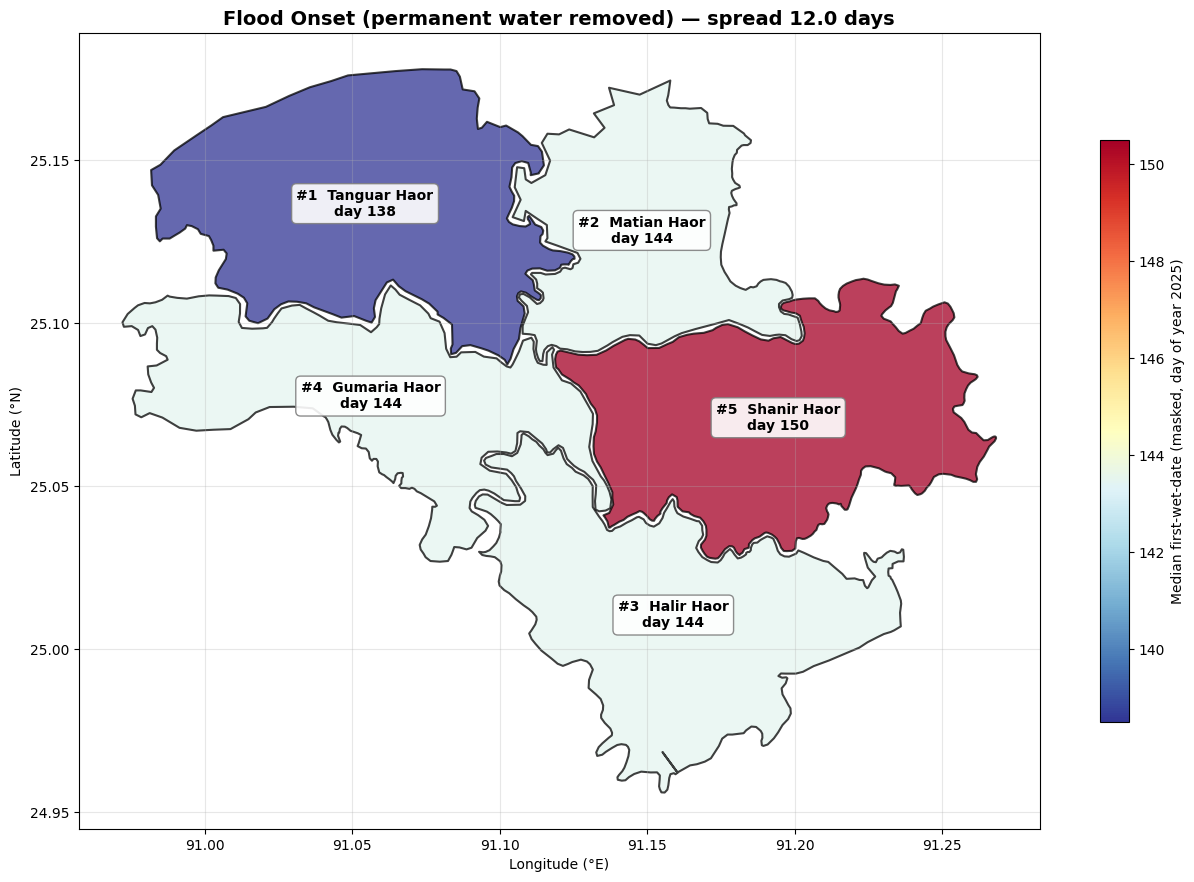

✓ Saved: /work/a06/wasif/haor_flood_analysis/digitization/analysis/haor_onset_sequence_masked.png

STEP C v3 COMPLETE — compare onset_std before/after; check box overlap


In [16]:
# %%
# === Map: haors colored by masked median ===
hplot = haors.merge(df[["haor_id", "onset_median"]], on="haor_id", how="left")
hplot = hplot.sort_values("onset_median").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 10))
hplot.plot(ax=ax, column="onset_median", cmap="RdYlBu_r",
           edgecolor="black", linewidth=1.5, alpha=0.75, legend=True,
           legend_kwds={"label": "Median first-wet-date (masked, day of year 2025)",
                        "orientation": "vertical", "shrink": 0.6})
for rank, (_, h) in enumerate(hplot.iterrows(), start=1):
    c = h.geometry.centroid
    ax.annotate(f"#{rank}  {h['name_en']}\nday {h['onset_median']:.0f}",
                (c.x, c.y), ha="center", va="center", fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                          edgecolor="gray", alpha=0.9))
ax.set_title(f"Flood Onset (permanent water removed) — spread {spread:.1f} days",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "haor_onset_sequence_masked.png"),
            dpi=180, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {os.path.join(ANALYSIS_DIR, 'haor_onset_sequence_masked.png')}")

print("\n" + "=" * 78)
print("STEP C v3 COMPLETE — compare onset_std before/after; check box overlap")
print("=" * 78)